# Crude Oil (CL) — Polymarket Price Analysis

Analyses the hourly YES-token prices fetched from Polymarket for the event  
**"Will Crude Oil (CL) hit__ by end of March?"**

**Sections**
1. Load & inspect data  
2. Price curves by strike  
3. Technical indicators (SMA, EMA, RSI, Bollinger Bands)  
4. Market-implied probability surface  
5. Signal generation & summary

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # project root on path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

# ── Load ──────────────────────────────────────────────────────────────────────
CSV = Path("../data/raw/polymarket/crude_oil_prices.csv")
df  = pd.read_csv(CSV, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

# Extract numeric strike value for sorting
df["strike_val"] = df["strike"].str.replace("$", "", regex=False).astype(int)

print(f"Rows : {len(df):,}")
print(f"Period: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Strikes ({df['strike_val'].nunique()}): {sorted(df['strike_val'].unique())}")
df.head(3)

Rows : 11,347
Period: 2026-02-28 → 2026-03-28
Strikes (21): [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 120, 130, 140, 150, 180, 200]


,event_slug,market_slug,direction,strike,token_id,timestamp,price,strike_val
0,will-crude-oil-cl-hit-by-end-of-march,will-crude-oil-cl-hit-high-100-by-end-of-march...,up,$100,7960566080699145781189043553716062897609950054...,2026-02-28 20:00:28+00:00,0.430,100
1,will-crude-oil-cl-hit-by-end-of-march,will-crude-oil-cl-hit-high-100-by-end-of-march...,up,$100,7960566080699145781189043553716062897609950054...,2026-02-28 21:00:30+00:00,0.200,100
2,will-crude-oil-cl-hit-by-end-of-march,will-crude-oil-cl-hit-high-100-by-end-of-march...,up,$100,7960566080699145781189043553716062897609950054...,2026-02-28 22:00:32+00:00,0.195,100


## 1 · Helper: per-market time-series

`get_series(strike, direction)` returns a clean hourly price Series indexed by UTC timestamp.

In [2]:
def get_series(strike: int, direction: str = "up") -> pd.Series:
    """Return hourly price Series for a given strike & direction."""
    mask = (df["strike_val"] == strike) & (df["direction"] == direction)
    s = (df[mask]
         .set_index("timestamp")["price"]
         .sort_index()
         .resample("1h").last()   # fill any duplicate ticks
         .dropna())
    s.name = f"{direction} ${strike}"
    return s


def add_indicators(s: pd.Series, sma_w=12, ema_w=12, bb_w=20) -> pd.DataFrame:
    """
    Attach technical indicators to a price series.

    Returns a DataFrame with columns:
        price, sma, ema, bb_upper, bb_lower, rsi
    """
    d = pd.DataFrame({"price": s})
    d["sma"]      = d["price"].rolling(sma_w).mean()
    d["ema"]      = d["price"].ewm(span=ema_w, adjust=False).mean()

    roll_mean     = d["price"].rolling(bb_w).mean()
    roll_std      = d["price"].rolling(bb_w).std()
    d["bb_upper"] = roll_mean + 2 * roll_std
    d["bb_lower"] = roll_mean - 2 * roll_std

    delta         = d["price"].diff()
    gain          = delta.clip(lower=0).rolling(14).mean()
    loss          = (-delta.clip(upper=0)).rolling(14).mean()
    rs            = gain / loss.replace(0, np.nan)
    d["rsi"]      = 100 - (100 / (1 + rs))
    return d

## 2 · Price curves — all "up" strikes

A quick overview of how each price level has moved over time.

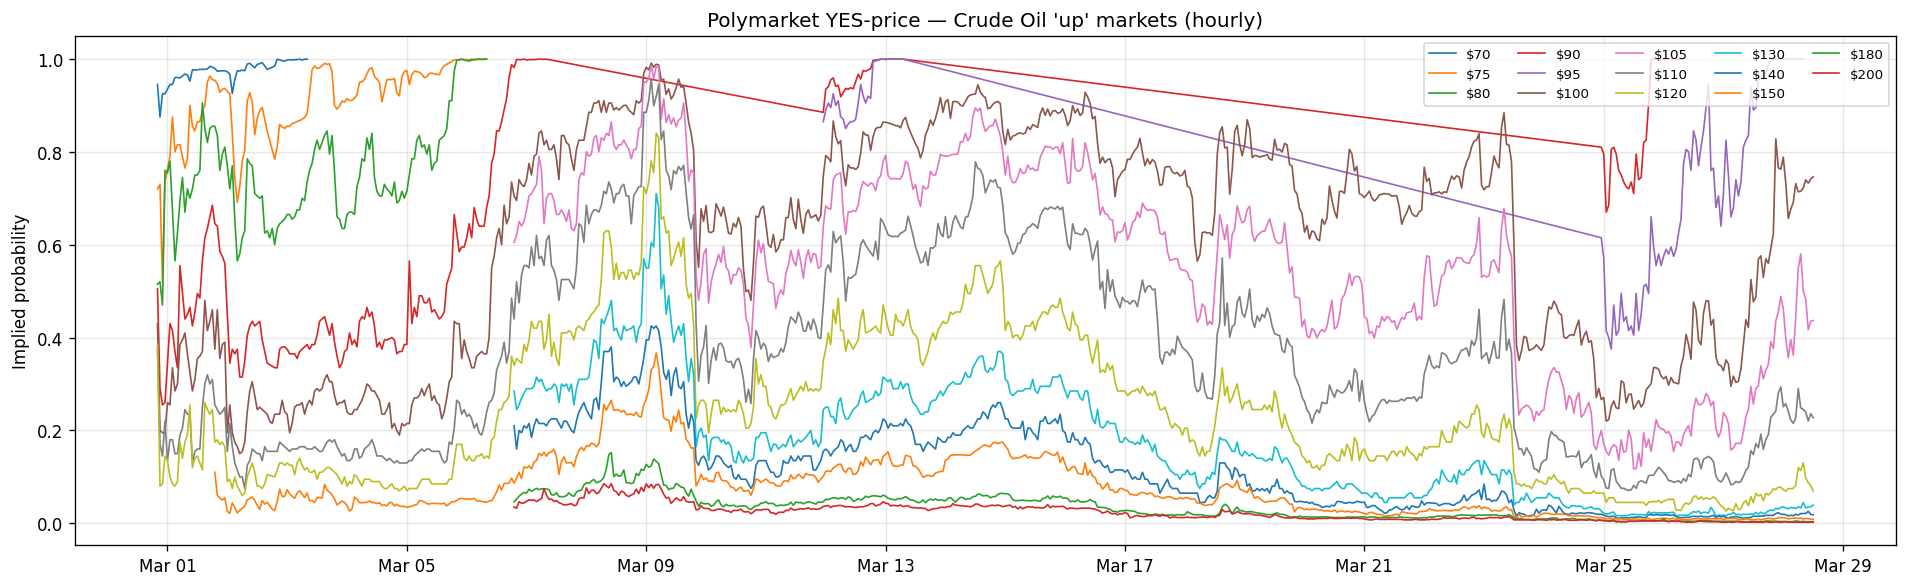

In [3]:
up_strikes = sorted(df[df["direction"] == "up"]["strike_val"].unique())

fig, ax = plt.subplots(figsize=(16, 5))
for strike in up_strikes:
    s = get_series(strike, "up")
    ax.plot(s.index, s.values, label=f"${strike}", linewidth=1)

ax.set_title("Polymarket YES-price — Crude Oil 'up' markets (hourly)")
ax.set_ylabel("Implied probability")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(ncol=5, fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Technical indicators for a single strike

Change `STRIKE` and `DIRECTION` to analyse any market.

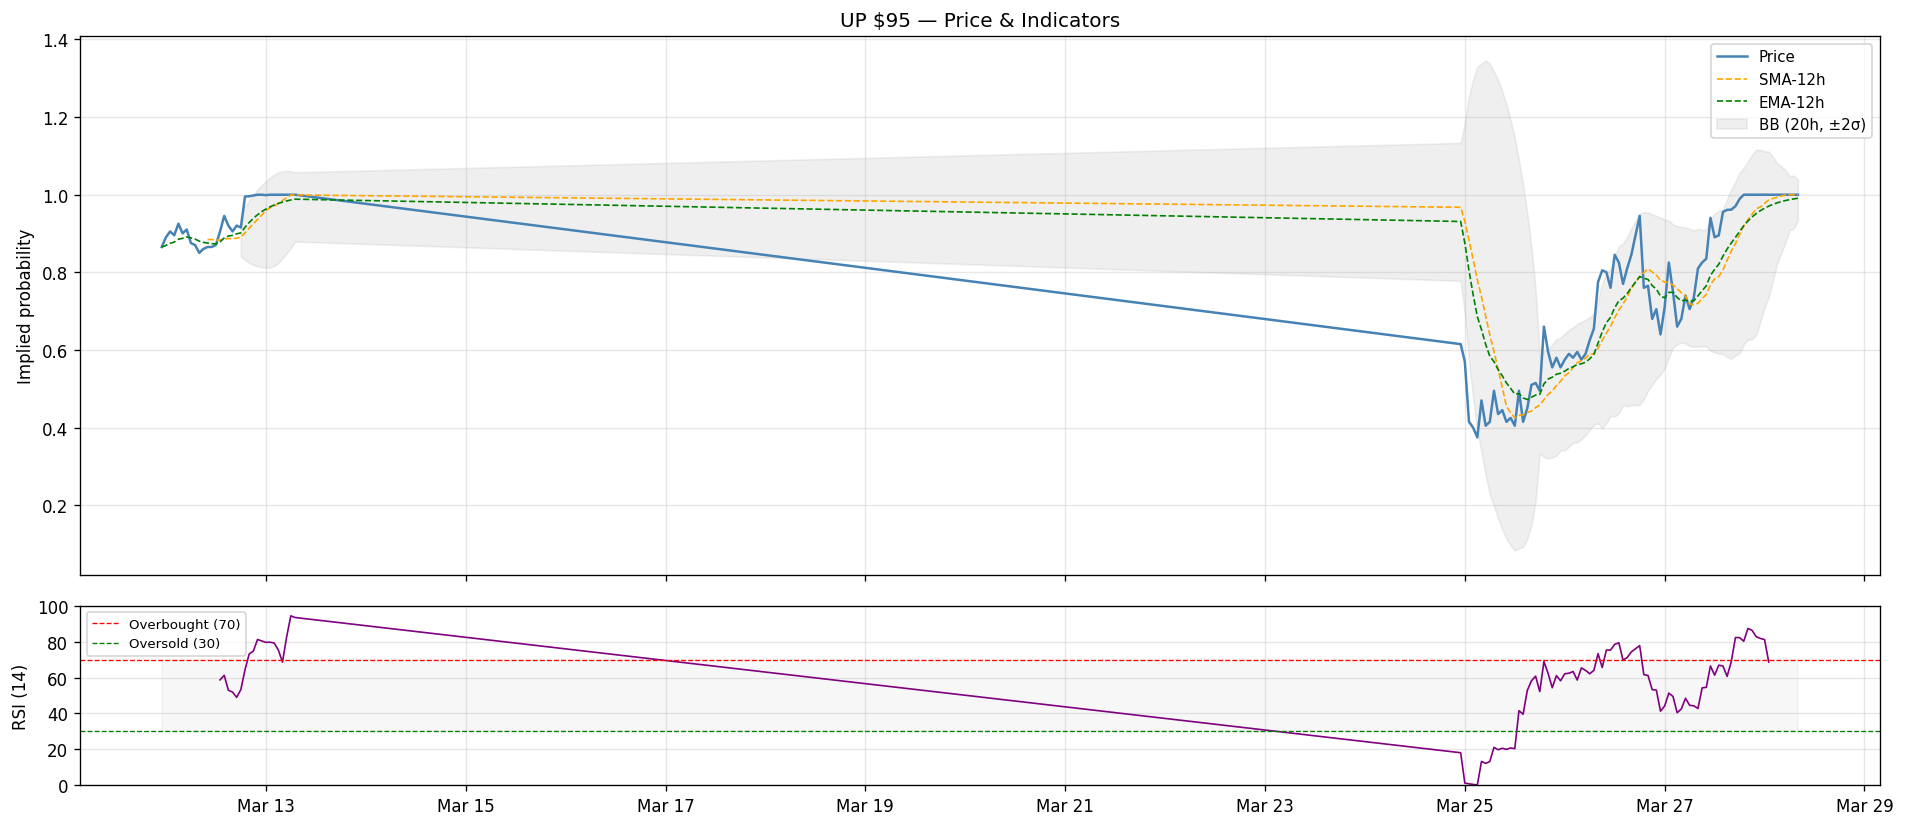

In [4]:
# ── Config — change these to explore other markets ───────────────────────────
STRIKE    = 95     # e.g. 95, 100, 105 …
DIRECTION = "up"   # "up" or "down"
# ─────────────────────────────────────────────────────────────────────────────

ind = add_indicators(get_series(STRIKE, DIRECTION))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# ── Price + SMA/EMA + Bollinger Bands ─────────────────────────────────────────
ax1.plot(ind.index, ind["price"],    label="Price",    color="steelblue", linewidth=1.5)
ax1.plot(ind.index, ind["sma"],      label="SMA-12h",  color="orange",    linewidth=1, linestyle="--")
ax1.plot(ind.index, ind["ema"],      label="EMA-12h",  color="green",     linewidth=1, linestyle="--")
ax1.fill_between(ind.index, ind["bb_lower"], ind["bb_upper"],
                 alpha=0.12, color="grey", label="BB (20h, ±2σ)")
ax1.set_title(f"{DIRECTION.upper()} ${STRIKE} — Price & Indicators")
ax1.set_ylabel("Implied probability")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── RSI ───────────────────────────────────────────────────────────────────────
ax2.plot(ind.index, ind["rsi"], color="purple", linewidth=1)
ax2.axhline(70, color="red",   linestyle="--", linewidth=0.8, label="Overbought (70)")
ax2.axhline(30, color="green", linestyle="--", linewidth=0.8, label="Oversold (30)")
ax2.fill_between(ind.index, 30, 70, alpha=0.06, color="grey")
ax2.set_ylabel("RSI (14)")
ax2.set_ylim(0, 100)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4 · Market-implied probability surface

Heatmap of the latest YES-price for every (direction × strike) combination — a snapshot of where the market thinks crude oil will end up.

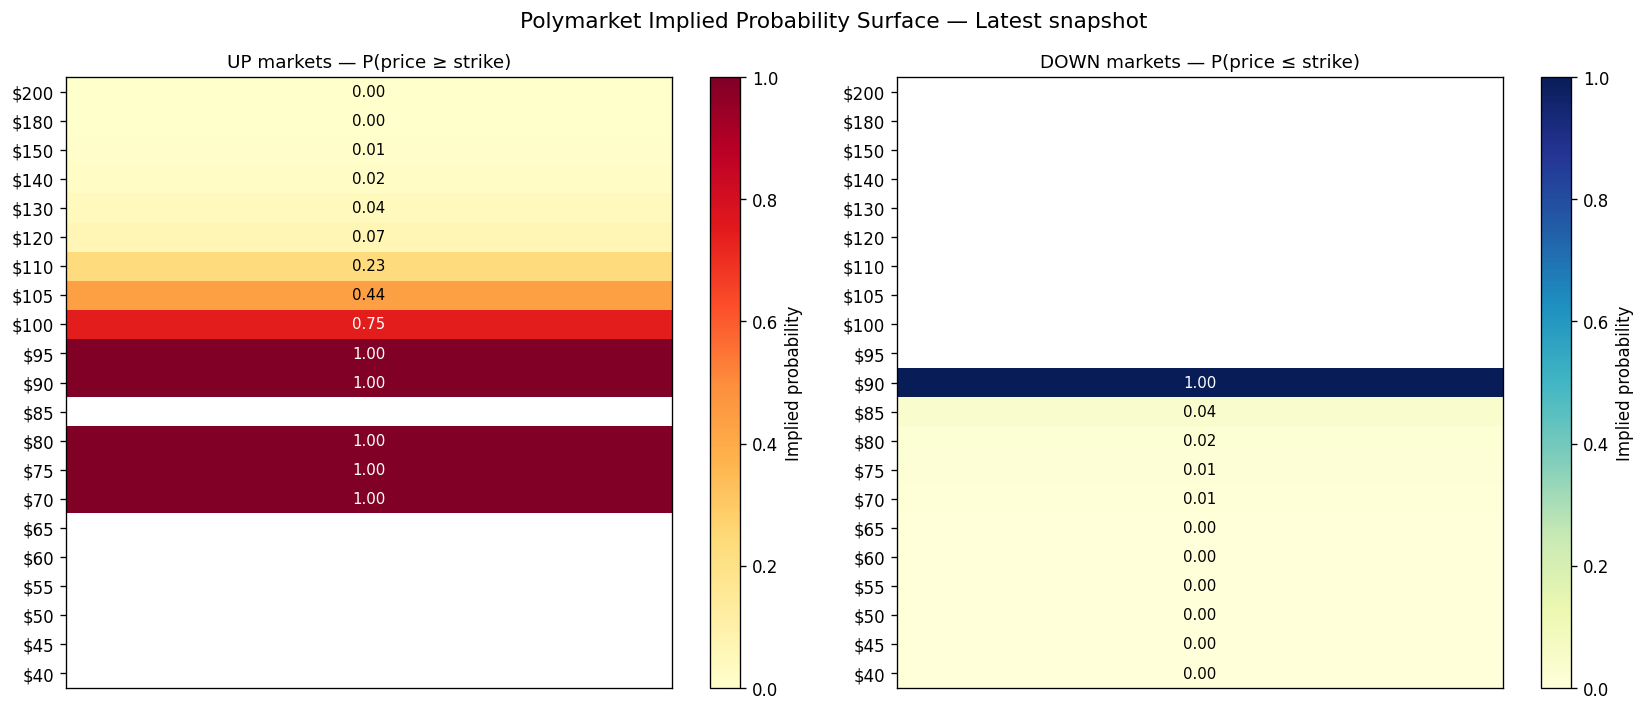

In [5]:
# Latest price for each (direction, strike)
latest = (df.sort_values("timestamp")
            .groupby(["direction", "strike_val"])["price"]
            .last()
            .unstack("direction")   # columns: down, up
            .sort_index())          # rows = strikes ascending

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, cmap, title in zip(
    axes,
    ["up", "down"],
    ["YlOrRd", "YlGnBu"],
    ["UP markets — P(price ≥ strike)", "DOWN markets — P(price ≤ strike)"]
):
    if col not in latest.columns:
        ax.set_visible(False)
        continue
    data = latest[[col]].rename(columns={col: "prob"})
    im = ax.imshow(data.values, aspect="auto", cmap=cmap, vmin=0, vmax=1,
                   origin="lower")
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels([f"${v}" for v in data.index])
    ax.set_xticks([])
    ax.set_title(title, fontsize=11)
    for i, val in enumerate(data["prob"]):
        ax.text(0, i, f"{val:.2f}", ha="center", va="center",
                color="black" if val < 0.7 else "white", fontsize=9)
    plt.colorbar(im, ax=ax, label="Implied probability")

plt.suptitle("Polymarket Implied Probability Surface — Latest snapshot", fontsize=13)
plt.tight_layout()
plt.show()

## 5 · Signal generation

Simple mean-reversion signal based on RSI and Bollinger Band penetration.  
A positive signal `+1` = market is oversold (buy YES), `-1` = overbought (sell YES).

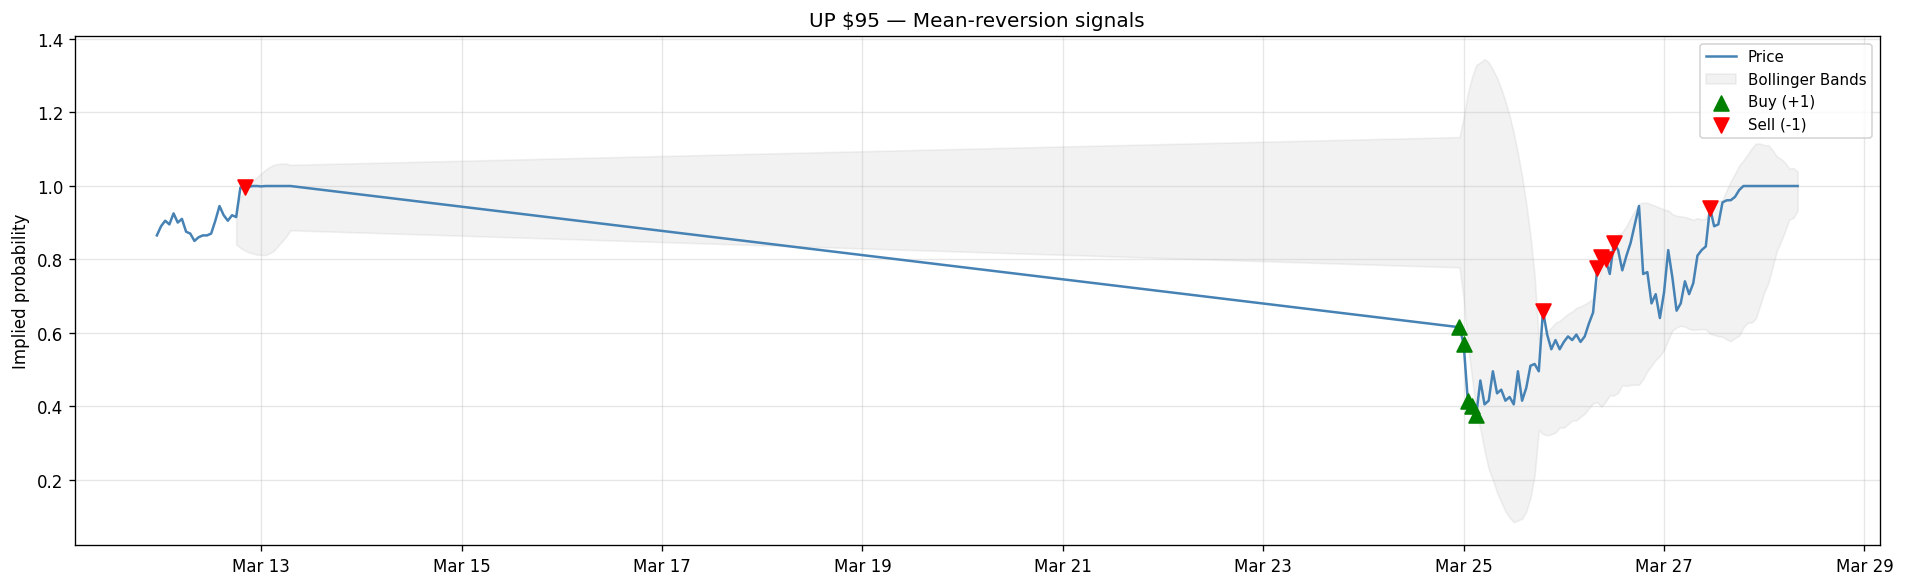


Signal counts:
signal
Sell      7
Flat    102
Buy       5
Name: count, dtype: int64


In [6]:
def generate_signals(ind: pd.DataFrame,
                     rsi_low: float  = 35,
                     rsi_high: float = 65) -> pd.DataFrame:
    """
    Mean-reversion signals:
      +1  price < BB lower  AND  RSI < rsi_low   → oversold, expect rebound
      -1  price > BB upper  AND  RSI > rsi_high  → overbought, expect fade
       0  no signal
    """
    sig = pd.Series(0, index=ind.index, name="signal")
    sig[(ind["price"] < ind["bb_lower"]) & (ind["rsi"] < rsi_low)]  =  1
    sig[(ind["price"] > ind["bb_upper"]) & (ind["rsi"] > rsi_high)] = -1
    return ind.assign(signal=sig)


# Apply to the selected market
ind_sig = generate_signals(ind)

# ── Plot signals on price chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ind_sig.index, ind_sig["price"], color="steelblue", linewidth=1.5, label="Price")
ax.fill_between(ind_sig.index, ind_sig["bb_lower"], ind_sig["bb_upper"],
                alpha=0.1, color="grey", label="Bollinger Bands")

buy_pts  = ind_sig[ind_sig["signal"] ==  1]
sell_pts = ind_sig[ind_sig["signal"] == -1]
ax.scatter(buy_pts.index,  buy_pts["price"],  marker="^", color="green", s=80, zorder=5, label="Buy (+1)")
ax.scatter(sell_pts.index, sell_pts["price"], marker="v", color="red",   s=80, zorder=5, label="Sell (-1)")

ax.set_title(f"{DIRECTION.upper()} ${STRIKE} — Mean-reversion signals")
ax.set_ylabel("Implied probability")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSignal counts:\n{ind_sig['signal'].value_counts().sort_index().rename({-1:'Sell',0:'Flat',1:'Buy'})}")

## 6 · Summary table — all markets

Latest price, 24h change, RSI, and current signal for every strike.

In [7]:
records = []
for direction in ["up", "down"]:
    for strike in sorted(df[df["direction"] == direction]["strike_val"].unique()):
        try:
            s   = get_series(strike, direction)
            ind_ = add_indicators(s)
            sig_ = generate_signals(ind_)
            last = sig_.iloc[-1]
            chg24 = last["price"] - sig_["price"].iloc[-25] if len(sig_) >= 25 else np.nan
            records.append({
                "direction": direction,
                "strike":    f"${strike}",
                "price":     round(last["price"], 3),
                "chg_24h":   round(chg24, 3),
                "rsi":       round(last["rsi"], 1),
                "signal":    {1: "Buy ▲", -1: "Sell ▼", 0: "—"}.get(last["signal"], "—"),
            })
        except Exception:
            continue

summary = pd.DataFrame(records)
summary.style \
    .background_gradient(subset=["price"], cmap="YlOrRd") \
    .background_gradient(subset=["rsi"],   cmap="RdYlGn_r") \
    .applymap(lambda v: "color: green" if v == "Buy ▲" else ("color: red" if v == "Sell ▼" else ""),
              subset=["signal"]) \
    .format({"price": "{:.3f}", "chg_24h": "{:+.3f}", "rsi": "{:.1f}"})

/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_70786/3536122808.py:22: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style \


,direction,strike,price,chg_24h,rsi,signal
0,up,$70,1.000,+0.026,81.4,—
1,up,$75,1.000,+0.028,89.3,—
2,up,$80,1.000,+0.205,95.0,—
3,up,$90,1.000,+0.265,98.5,—
4,up,$95,1.000,+0.190,nan,—
5,up,$100,0.746,+0.269,46.7,—
6,up,$105,0.436,+0.180,48.5,—
7,up,$110,0.228,+0.080,40.2,—
8,up,$120,0.069,+0.025,46.9,—
9,up,$130,0.040,+0.020,58.8,—
